# Exercício prático 1 
## Análise de dados: Finanças Pessoais


### Passo a passo:
1. 🧹 **Limpeza dos dados**
2. 📊 **Análise exploratória**
3. 📈 **Visualizações informativas**
4. 🔍 **Identificação de insights**
5. 📋 **Conclusões e recomendações**

# Escolhendo o dataset

# Carregando e Preparando os Dados
1. ***Carregar*** o dataset
2. ***Explorar*** a estrutura dos dados
3. ***Limpar*** valores ausentes
4. ***Preparar*** para análise

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Carregando dataset Finaças Pessoais')
df = pd.read_csv('https://raw.githubusercontent.com/lucasalmo/lia1_2026_1/refs/heads/main/Entregas%20-%20Lucas%20Almeida%20Moreira/synthetic_personal_finance_dataset.csv')

print('Informações básicas do dataset:')
print(f'Dimensões: {df.shape}')
print(f'Colunas: {list(df.columns)}')

print('\nUm pouco sobre o Dataset:')
df.tail(50)

Carregando dataset Finaças Pessoais
Informações básicas do dataset:
Dimensões: (32424, 20)
Colunas: ['user_id', 'age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio', 'region', 'record_date']

Um pouco sobre o Dataset:


,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
32374,U32375,54,Male,Master,Employed,Unemployed,2855.97,1615.22,142740.19,Yes,Business,264131.02,36,8976.14,13.60,3.14,359,4.16,Asia,2024-02-06
32375,U32376,49,Female,High School,Self-employed,Engineer,3614.40,2735.76,160450.96,No,NaN,0.00,0,0.00,0.00,0.00,428,3.70,Other,2023-01-15
32376,U32377,21,Female,PhD,Employed,Student,2210.12,1397.49,93362.99,No,NaN,0.00,0,0.00,0.00,0.00,324,3.52,Asia,2024-10-16
32377,U32378,22,Female,Bachelor,Student,Accountant,6100.78,2020.55,419823.54,No,NaN,0.00,0,0.00,0.00,0.00,408,5.73,Africa,2023-08-20
32378,U32379,26,Male,Bachelor,Self-employed,Student,3983.68,1559.77,103153.71,No,NaN,0.00,0,0.00,0.00,0.00,585,2.16,Asia,2021-08-19
32379,U32380,63,Female,Bachelor,Self-employed,Unemployed,2729.33,1441.33,74863.90,Yes,Home,18286.52,60,344.17,4.89,0.13,316,2.29,Europe,2021-09-02
32380,U32381,58,Male,Master,Employed,Salesperson,5221.91,2823.92,192872.48,Yes,Business,188804.71,12,16311.43,6.71,3.12,301,3.08,Other,2023-06-10
32381,U32382,43,Female,Master,Employed,Engineer,1769.79,826.44,107778.60,Yes,Car,371087.98,240,7336.97,23.50,4.15,414,5.07,Africa,2023-02-11
32382,U32383,34,Male,High School,Employed,Unemployed,6035.69,2981.74,461918.30,Yes,Education,10907.79,120,167.14,13.66,0.03,530,6.38,Europe,2022-08-02
32383,U32384,53,Female,Bachelor,Employed,Salesperson,2940.34,1752.36,82545.18,No,NaN,0.00,0,0.00,0.00,0.00,618,2.34,North America,2024-03-15


## Limpando os dados

In [85]:
print('Verificando dados ausentes:')
da = df.isnull().sum()
print(da[da > 0])

# Limpando os dados
print('Realizando limpeza dos dados')

# 1. Removendo coluna 'loan_type' pode ter muitos dados faltando
if 'loan_type' in df.columns:
    df = df.drop('loan_type', axis=1)


Verificando dados ausentes:
loan_type    19429
dtype: int64
Realizando limpeza dos dados


In [68]:
# Limpando os dados
df_limpo = df.copy()

# 1. Removendo linhas com grau de escolaridade e gênero que estão como outro para ter resultados mais precisos
#df_limpo = df_limpo[df_limpo['education_level'] != 'Other']

df_limpo.head(50)

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07
5,U00006,62,Male,Master,Employed,Student,4051.00,2244.42,194901.41,Yes,Car,407915.25,12,38219.81,22.21,9.43,718,4.01,North America,2025-02-12
6,U00007,22,Female,Master,Student,Accountant,983.69,332.62,37522.56,Yes,Car,296057.60,180,6773.29,26.95,6.89,761,3.18,Asia,2024-06-01
7,U00008,18,Female,Bachelor,Employed,Accountant,6199.29,4503.15,89107.54,No,NaN,0.00,0,0.00,0.00,0.00,540,1.20,Africa,2024-03-17
8,U00009,49,Female,High School,Self-employed,Doctor,4271.51,3062.12,451923.96,No,NaN,0.00,0,0.00,0.00,0.00,327,8.82,Africa,2023-05-02
9,U00010,61,Male,Master,Employed,Student,5216.18,4369.36,203320.50,Yes,Education,324197.37,360,6782.37,25.09,1.30,558,3.25,Asia,2024-11-23


## Problema a ser resolvido
***O grau de escolaridade influencia a probabilidade de uma pessoa fazer empréstimo?***

## Visualizando os dados

In [53]:
# Verificando dados por categoria de gênero
df['gender'].value_counts()

gender
Male      15595
Female    15550
Other      1279
Name: count, dtype: int64

In [71]:
ordem = ['High School', 'Bachelor', 'Master', 'PhD', 'Other']

df_limpo["education_level"] = pd.Categorical(df_limpo["education_level"], categories=ordem, ordered=True)

In [70]:
pd.crosstab(df_limpo['education_level'], df_limpo['has_loan'])

has_loan,No,Yes
education_level,,
High School,3807,2649
Bachelor,7890,5148
Master,5783,3890
PhD,995,643
Other,954,665


In [72]:
# Em percentual
pd.crosstab(
    df_limpo['education_level'],
    df_limpo['has_loan'],
    normalize='index'
)

has_loan,No,Yes
education_level,,
High School,0.589684,0.410316
Bachelor,0.605154,0.394846
Master,0.597850,0.402150
PhD,0.607448,0.392552
Other,0.589253,0.410747


In [73]:
df_limpo.groupby("education_level")["has_loan"].value_counts(normalize=True)

/tmp/ipykernel_153561/1790150494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpo.groupby("education_level")["has_loan"].value_counts(normalize=True)


education_level  has_loan
High School      No          0.589684
                 Yes         0.410316
Bachelor         No          0.605154
                 Yes         0.394846
Master           No          0.597850
                 Yes         0.402150
PhD              No          0.607448
                 Yes         0.392552
Other            No          0.589253
                 Yes         0.410747
Name: proportion, dtype: float64

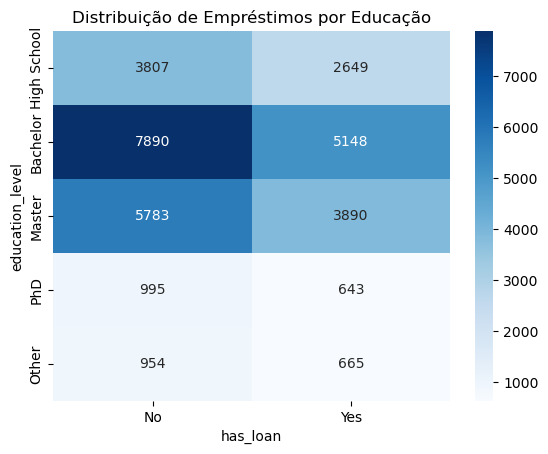

In [74]:
tabela = pd.crosstab(df_limpo["education_level"], df_limpo["has_loan"])

sns.heatmap(tabela, annot=True, fmt="d", cmap="Blues")

plt.title("Distribuição de Empréstimos por Educação")

plt.show()

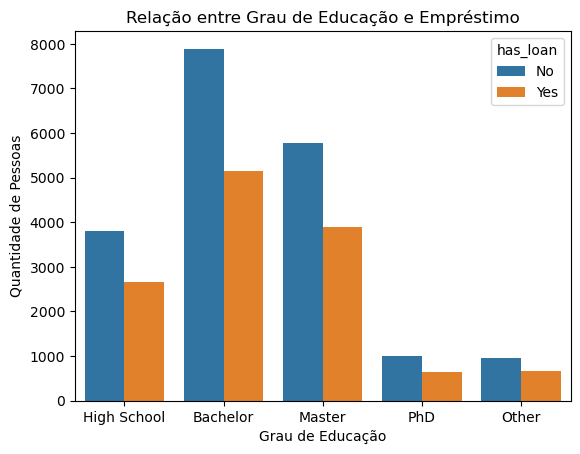

In [78]:
sns.countplot(data=df_limpo, x="education_level", hue="has_loan")

plt.title("Relação entre Grau de Educação e Empréstimo")
plt.xlabel("Grau de Educação")
plt.ylabel("Quantidade de Pessoas")

plt.show()

In [ ]:
# 